In [35]:
# ==========================================================
# BLOQUE 1: CARGA DE DATOS, TOP 9 Y PREPARACIÓN DEL GRAFO GLOBAL
# ==========================================================


import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from collections import Counter

import matplotlib.colors as mcolors
import matplotlib.cm as cm

trayectorias = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx", sheet_name=2)



# 1. Obtenemos el Top 9 de rutas más frecuentes
# (Asumimos que el dataframe 'trayectorias_trayectoria' o 'trayectorias' ya está creado con la columna)
top_9_rutas = trayectorias['ruta_complejidad_str'].value_counts().head(9)

# 2. Preparación de diccionarios para contar nodos y transiciones globales
apariciones_nodos = Counter()
transiciones = Counter()

for ruta in trayectorias['ruta_complejidad_str'].dropna():
    nodos = [n.strip() for n in str(ruta).split('->')]
    
    # Frecuencia de nodos individuales
    for n in nodos:
        apariciones_nodos[n] += 1
        
    # Frecuencia de aristas (transiciones entre un nodo y el siguiente)
    for i in range(len(nodos)-1):
        transiciones[(nodos[i], nodos[i+1])] += 1

# 3. Creación del objeto Grafo Global de NetworkX
G_global = nx.DiGraph()

for nodo, count in apariciones_nodos.items():
    G_global.add_node(nodo, weight=count)
    
for (origen, destino), count in transiciones.items():
    G_global.add_edge(origen, destino, weight=count)


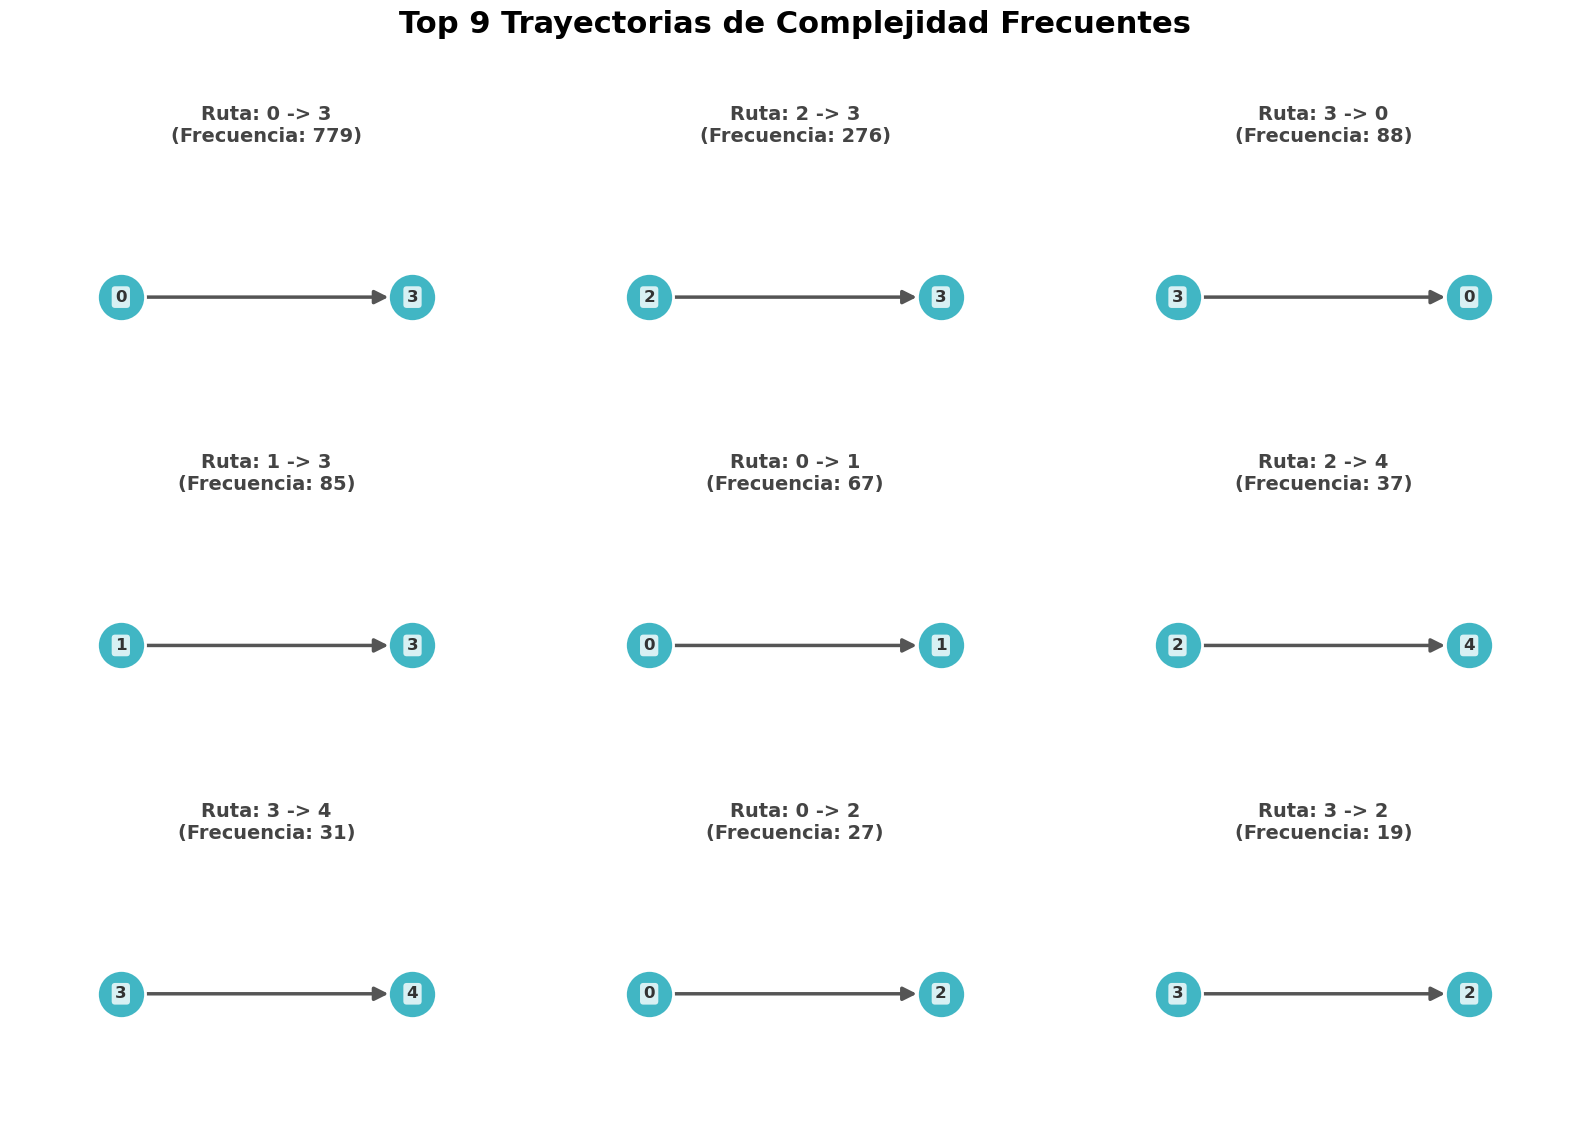

In [36]:
# ==========================================================
# BLOQUE 2: GRAFICAR LAS 9 RUTAS PRINCIPALES (CUADRÍCULA 3x3)
# ==========================================================
fig1, axes = plt.subplots(3, 3, figsize=(16, 12))
fig1.patch.set_facecolor('white') 
fig1.suptitle('Top 9 Trayectorias de Complejidad Frecuentes', fontsize=22, fontweight='bold', y=0.95)
axes = axes.flatten()

for idx, (ruta, cantidad) in enumerate(top_9_rutas.items()):
    ax = axes[idx]
    ax.axis('off')
    
    nodos = [n.strip() for n in str(ruta).split('->')]
    G_mini = nx.DiGraph()
    
    for i in range(len(nodos)-1):
        G_mini.add_edge(nodos[i], nodos[i+1])
        
    posiciones = {nodo: (i, 0) for i, nodo in enumerate(nodos)}
    
    # Renderizado estilo "Mapa PBA" (Nodos con borde blanco)
    nx.draw_networkx_nodes(G_mini, posiciones, ax=ax, node_color='#41b6c4', 
                           node_size=1200, edgecolors='white', linewidths=2.0)
    
    nx.draw_networkx_edges(G_mini, posiciones, ax=ax, edge_color='#555555', 
                           width=2.5, arrowstyle='-|>', arrowsize=20, node_size=1200)
    
    # Cajas de texto (Bbox) para las etiquetas
    nx.draw_networkx_labels(G_mini, posiciones, ax=ax, font_size=12, font_weight='bold', font_color='#333333',
                            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    
    ax.set_title(f"Ruta: {ruta}\n(Frecuencia: {cantidad})", fontsize=14, fontweight='bold', color='#444444', pad=10)
    ax.margins(0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92]) 
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_27764\2856043525.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_nodos = cm.get_cmap('RdYlGn_r')


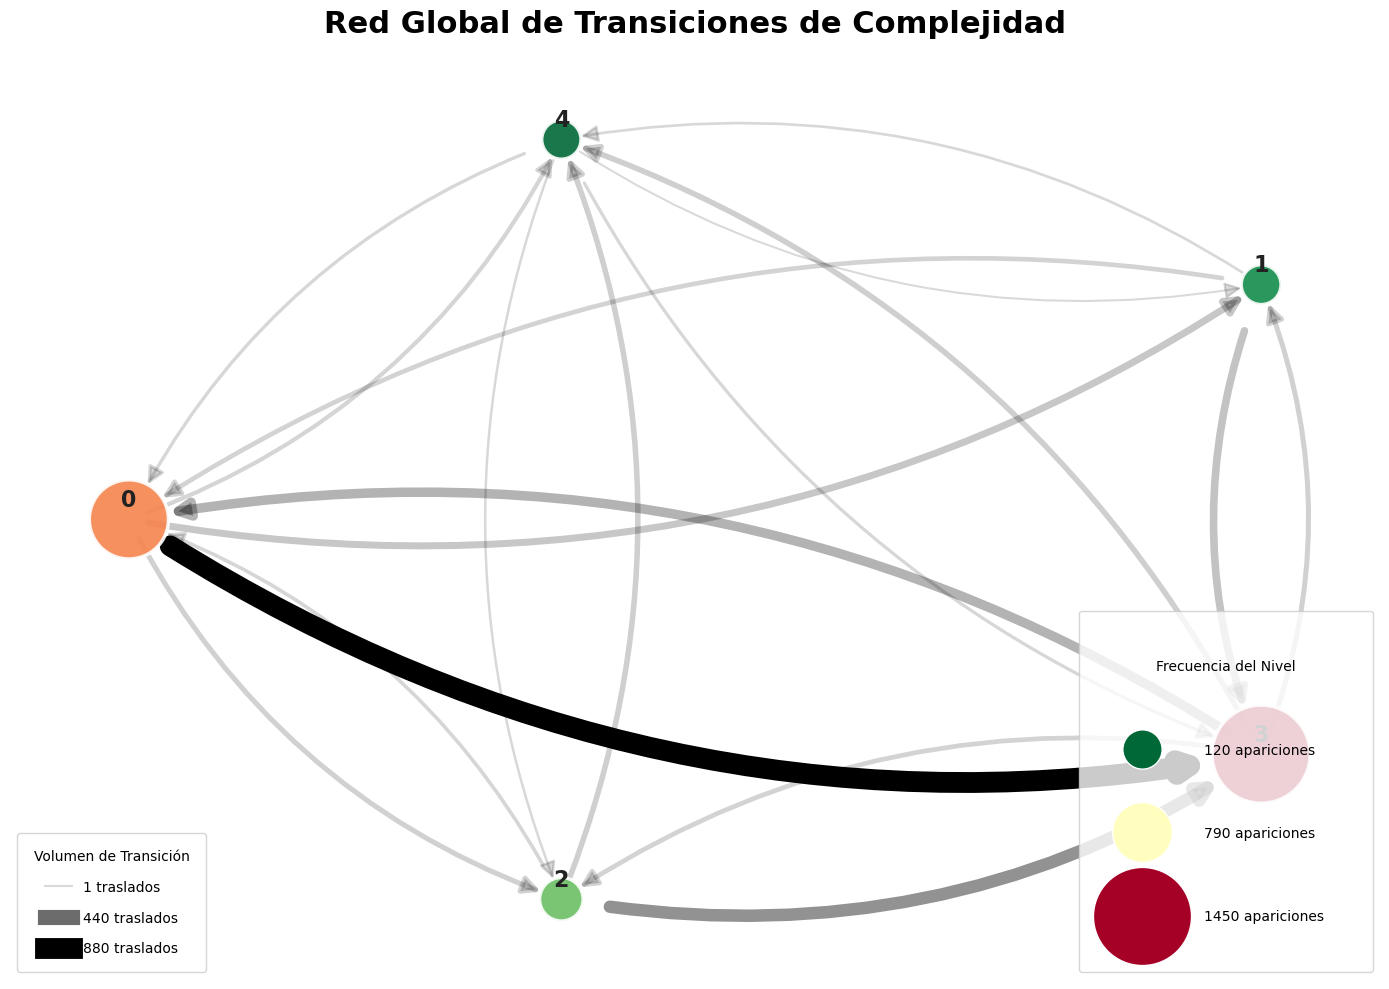

In [41]:
# ==========================================================
# BLOQUE 3: GRAFICAR EL GRAFO GLOBAL DE TRANSICIONES
# ==========================================================

# 0. Eliminar aristas que van de un nodo a sí mismo (Self-loops)
G_global.remove_edges_from(list(nx.selfloop_edges(G_global)))

# 1. Variables de estilo y escalas
MIN_GROSOR_ARISTA, MAX_GROSOR_ARISTA = 1.0, 15.0
MIN_TAMANO_NODO, MAX_TAMANO_NODO = 800, 5000    

pesos_aristas = [d['weight'] for u, v, d in G_global.edges(data=True)]
pesos_nodos = [d['weight'] for n, d in G_global.nodes(data=True)]

MAX_TRASLADOS = max(pesos_aristas) if pesos_aristas else 1
MIN_TRASLADOS = min(pesos_aristas) if pesos_aristas else 0
MIN_INGRESOS = min(pesos_nodos) if pesos_nodos else 0
MAX_INGRESOS = max(pesos_nodos) if pesos_nodos else 1

# Funciones de escala
def calc_grosor(peso):
    if MAX_TRASLADOS == 0: return MIN_GROSOR_ARISTA
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_node_size(ingreso):
    if MAX_INGRESOS == MIN_INGRESOS: return MIN_TAMANO_NODO
    escala_lineal = (ingreso - MIN_INGRESOS) / (MAX_INGRESOS - MIN_INGRESOS)
    return MIN_TAMANO_NODO + ((escala_lineal ** 2) * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))

def calc_legend_markersize(ingreso):
    return np.sqrt(calc_node_size(ingreso))

def calc_alpha(peso):
    if MAX_TRASLADOS == MIN_TRASLADOS: return 0.7
    escala = (peso - MIN_TRASLADOS) / (MAX_TRASLADOS - MIN_TRASLADOS)
    alpha_calculado = 0.15 + (escala * 0.85)
    # CORRECCIÓN: Forzamos a que siempre esté contenido entre 0.0 y 1.0
    return min(1.0, max(0.0, alpha_calculado))

def redondear_leyenda(valor):
    if valor <= 5: return max(1, int(round(valor)))
    return int(round(valor / 10.0)) * 10

# 2. Preparar la figura
fig2, ax2 = plt.subplots(figsize=(14, 10))
fig2.patch.set_facecolor('white')
ax2.set_title('Red Global de Transiciones de Complejidad', fontsize=22, fontweight='bold', pad=20)
ax2.axis('off')

# Posiciones
pos = nx.shell_layout(G_global) 

# Configuración de Colores (Verde -> Amarillo -> Naranja -> Rojo)
cmap_nodos = cm.get_cmap('RdYlGn_r')
norm_nodos = mcolors.Normalize(vmin=MIN_INGRESOS, vmax=MAX_INGRESOS)

# 3. Renderizado de Nodos
nodelist = list(G_global.nodes())
node_sizes = [calc_node_size(G_global.nodes[n]['weight']) for n in nodelist]
node_colors = [cmap_nodos(norm_nodos(G_global.nodes[n]['weight'])) for n in nodelist]

nx.draw_networkx_nodes(G_global, pos, nodelist=nodelist, ax=ax2,
                       node_color=node_colors, node_size=node_sizes, 
                       alpha=0.9, edgecolors='white', linewidths=2.5)

# 4. Renderizado de Aristas
for u, v, data in G_global.edges(data=True):
    peso = data['weight']
    nx.draw_networkx_edges(G_global, pos, edgelist=[(u, v)], ax=ax2,
                           width=calc_grosor(peso), 
                           edge_color='black',          
                           alpha=calc_alpha(peso),      
                           arrowstyle='-|>', arrowsize=25, connectionstyle="arc3,rad=0.2",
                           node_size=calc_node_size(G_global.nodes[v]['weight'])) 

# 5. Renderizado de Etiquetas (Texto libre)
pos_labels = {k: (v[0], v[1] + 0.05) for k, v in pos.items()} 
nx.draw_networkx_labels(G_global, pos_labels, ax=ax2, font_size=16, font_weight='bold', font_color='#222222')

# 6. Leyendas Dinámicas
v_min, v_max = MIN_TRASLADOS, MAX_TRASLADOS
v_med = (v_min + v_max) / 2
i_min, i_max = MIN_INGRESOS, MAX_INGRESOS
i_med = (i_min + i_max) / 2

# Valores redondeados
v_min_v, v_med_v, v_max_v = redondear_leyenda(v_min), redondear_leyenda(v_med), redondear_leyenda(v_max)
i_min_v, i_med_v, i_max_v = redondear_leyenda(i_min), redondear_leyenda(i_med), redondear_leyenda(i_max)

proxies_volumen = [
    mlines.Line2D([], [], color='black', alpha=calc_alpha(v_min_v), linewidth=calc_grosor(v_min_v), label=f'{v_min_v} traslados'),
    mlines.Line2D([], [], color='black', alpha=calc_alpha(v_med_v), linewidth=calc_grosor(v_med_v), label=f'{v_med_v} traslados'),
    mlines.Line2D([], [], color='black', alpha=calc_alpha(v_max_v), linewidth=calc_grosor(v_max_v), label=f'{v_max_v} traslados')
]

proxies_nodos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=cmap_nodos(norm_nodos(i_min_v)), markersize=calc_legend_markersize(i_min_v), label=f'{i_min_v} apariciones'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=cmap_nodos(norm_nodos(i_med_v)), markersize=calc_legend_markersize(i_med_v), label=f'{i_med_v} apariciones'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=cmap_nodos(norm_nodos(i_max_v)), markersize=calc_legend_markersize(i_max_v), label=f'{i_max_v} apariciones')
]

leg1 = ax2.legend(handles=proxies_volumen, title="Volumen de Transición", loc='lower left', frameon=True, borderpad=1.2, labelspacing=1.2)
ax2.add_artist(leg1)
ax2.legend(handles=proxies_nodos, title="Frecuencia del Nivel", loc='lower right', frameon=True, borderpad=3.5, labelspacing=5, handletextpad=3.5)

plt.tight_layout()
plt.show()